In [46]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import os
import joblib

import load.load_dataset as ds
import load.load_net as nt
import load.nets.training as tr

import torch
from sklearn.metrics import roc_auc_score, roc_curve, ConfusionMatrixDisplay

# **Tuning of hyperparameters to train model**

In [47]:
def plot_roc(y_val, result1, result2, result3, result4, result5, result6, result7, dataset_name, class_idx = None):
    y_val_labels = y_val.detach().numpy().argmax(axis=1)
    
    roc1 = roc_auc_score(y_val_labels, result1['pred_proba'][0][:,1])
    fpr1, tpr1, _ = roc_curve(y_val_labels, result1['pred_proba'][0][:,1])
    
    roc2 = roc_auc_score(y_val_labels, result2['pred_proba'][0][:,1])
    fpr2, tpr2, _ = roc_curve(y_val_labels, result2['pred_proba'][0][:,1])
    
    roc3 = roc_auc_score(y_val_labels, result3['pred_proba'][0][:,1])
    fpr3, tpr3, _ = roc_curve(y_val_labels, result3['pred_proba'][0][:,1])
    
    roc4 = roc_auc_score(y_val_labels, result4['pred_proba'][0][:,1])
    fpr4, tpr4, _ = roc_curve(y_val_labels, result4['pred_proba'][0][:,1])
    
    roc5 = roc_auc_score(y_val_labels, result5['pred_proba'][0][:,1])
    fpr5, tpr5, _ = roc_curve(y_val_labels, result5['pred_proba'][0][:,1])
    
    roc6 = roc_auc_score(y_val_labels, result6['pred_proba'][0][:,1])
    fpr6, tpr6, _ = roc_curve(y_val_labels, result6['pred_proba'][0][:,1])
    
    roc7 = roc_auc_score(y_val_labels, result7['pred_proba'][0][:,1])
    fpr7, tpr7, _ = roc_curve(y_val_labels, result7['pred_proba'][0][:,1])

    fig, ax = plt.subplots(1, 2, figsize=(18, 6))

    plt.figure(figsize=(6,6))
    ax[0].plot(fpr1, tpr1, color='black', label=f'ROC smallNN - {roc1:.4f}')
    ax[0].plot(fpr2, tpr2, color='red', label=f'ROC regNN 0.3 - {roc2:.4f}')
    ax[0].plot(fpr3, tpr3, color='green', label=f'ROC regNN 0.1 - {roc3:.4f}')
    ax[0].plot(fpr4, tpr4, color='purple', label=f'ROC ResNet - {roc4:.4f}')
    ax[0].plot([0,1],[0,1], color='grey', linestyle='--', label='Random')
    ax[0].set_xlabel('False Positive Rate')
    ax[0].set_ylabel('True Positive Rate')
    ax[0].legend()
    
    ax[1].plot(fpr1, tpr1, color='black', label=f'ROC smallNN - {roc1:.4f}')
    ax[1].plot(fpr5, tpr5, color='red', label=f'ROC CNN1 - {roc5:.4f}')
    ax[1].plot(fpr6, tpr6, color='green', label=f'ROC CNN2 - {roc6:.4f}')
    ax[1].plot(fpr7, tpr7, color='blue', label=f'ROC CNN3 - {roc7:.4f}')
    ax[1].plot([0,1],[0,1], color='grey', linestyle='--', label='Random')
    ax[1].set_xlabel('False Positive Rate')
    ax[1].set_ylabel('True Positive Rate')
    ax[1].legend()
    
    plt.tight_layout()
    plt.show()


In [48]:
def plot_conf_matrix(y_val, result1, result2, result3, title = ['', '', '']):
    cm1 = result1['confusion_matrix'][0]
    cm2 = result2['confusion_matrix'][0]
    cm3 = result3['confusion_matrix'][0]
    fig, ax = plt.subplots(1, 3, figsize=(18, 6))
    disp1 = ConfusionMatrixDisplay(confusion_matrix=cm1)
    disp2 = ConfusionMatrixDisplay(confusion_matrix=cm2)
    disp3 = ConfusionMatrixDisplay(confusion_matrix=cm3)
    ax[0].set_title(title[0])
    ax[1].set_title(title[1])
    ax[2].set_title(title[2])
    disp1.plot(cmap=plt.cm.Blues, ax=ax[0])
    disp2.plot(cmap=plt.cm.Blues, ax=ax[1])
    disp3.plot(cmap=plt.cm.Blues, ax=ax[2])
    plt.show()

In [49]:
def eval_net(dataset_name, model_name):
    
    history = joblib.load(f'./models/histories/{dataset_name}_{model_name}_history.joblib')
    axis = np.linspace(0, len(history['train_loss']), len(history['train_loss']))
    fig, ax = plt.subplots(1, 2, figsize = [12,5])
    ax[0].plot(axis, history['train_loss'], label='Train Loss')
    ax[0].plot(axis, history['val_loss'], label='Val Loss')
    ax[0].set_title('Loss')
    ax[0].legend()

    ax[1].plot(axis, history['train_acc'], label='Train Accuracy')
    ax[1].plot(axis, history['val_acc'], label='Val Accuracy')
    ax[1].set_title('Accuracy')
    ax[1].legend()

    plt.tight_layout()
    plt.show()
    results = joblib.load(f'./models/results/{dataset_name}_{model_name}_results.joblib')
    print(results['classification_report'][0])
    return results


## **ADULT**

In [ ]:
dataset_name = "adult"
net = nt.load_net(dataset_name)
dataset = ds.Dataset(dataset_name)

feature_names, categorical_features, categorical_names, ordinal, discrete, encoder, num_features = dataset.info()
X_train_or, X_train, y_train = dataset.train()
X_val_or, X_val, y_val = dataset.validation()
X_test_or, X_test, y_test = dataset.test()
print(X_train_or.shape, X_val_or.shape, X_test_or.shape)

adult_smallNN = eval_net(dataset_name, 'model4')

adult_regNN_03 = eval_net(dataset_name, 'model5')
adult_regNN_01 = eval_net(dataset_name, 'model8')
adult_ResNet = eval_net(dataset_name, 'model9')

adult_CNN1  = eval_net(dataset_name, 'model6')
adult_CNN2  = eval_net(dataset_name, 'model7')
adult_CNN3  = eval_net(dataset_name, 'model10')

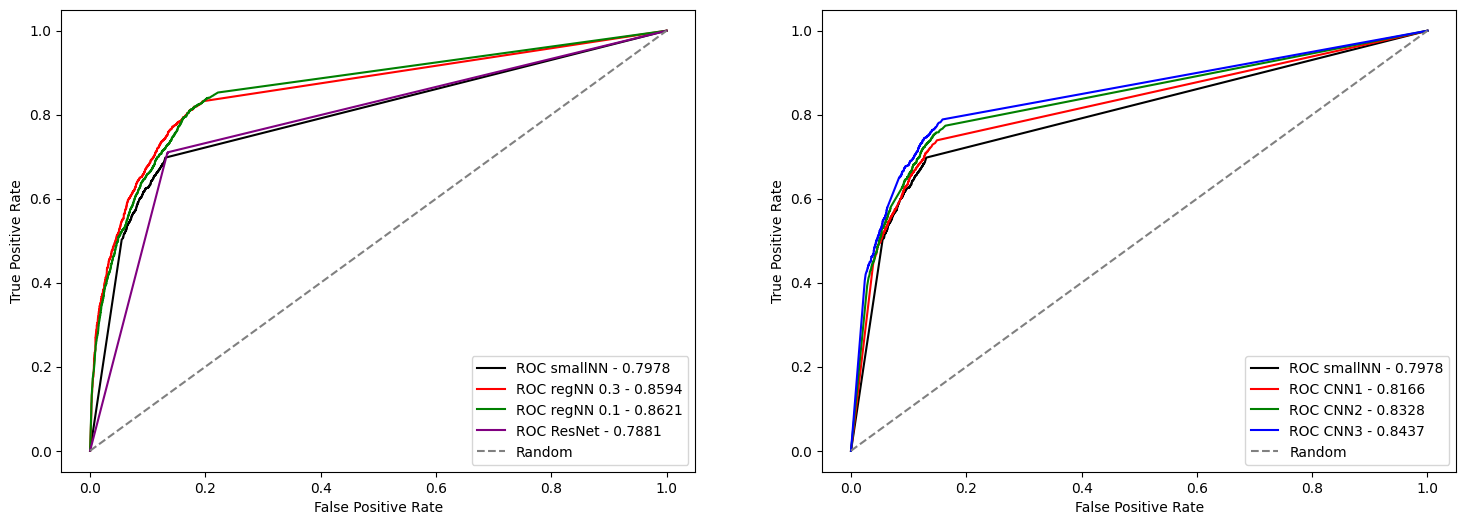

<Figure size 600x600 with 0 Axes>

In [51]:
plot_roc(y_val, adult_smallNN, adult_regNN_03, adult_regNN_01, adult_ResNet, adult_CNN1, adult_CNN2, adult_CNN3, dataset_name)

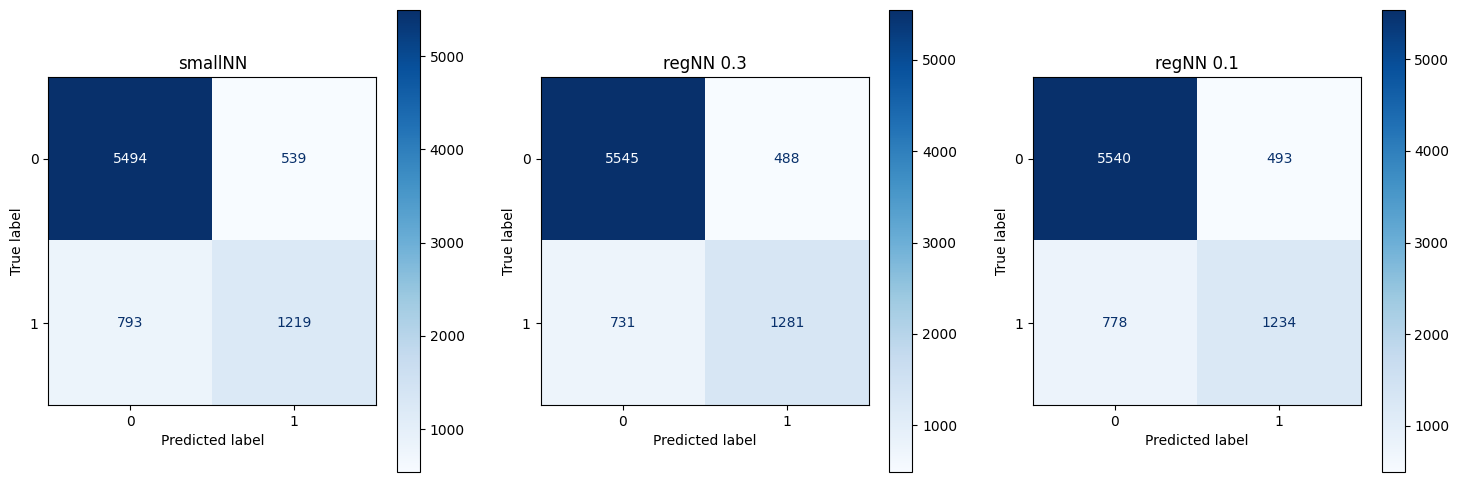

In [52]:
plot_conf_matrix(y_val, adult_smallNN, adult_regNN_03, adult_regNN_01, title = ['smallNN', 'regNN 0.3', 'regNN 0.1'])

## **BANK**

In [ ]:
dataset_name = "bank"
net = nt.load_net(dataset_name)
dataset = ds.Dataset(dataset_name)

feature_names, categorical_features, categorical_names, ordinal, discrete, encoder, num_features = dataset.info()
X_train_or, X_train, y_train = dataset.train()
X_val_or, X_val, y_val = dataset.validation()
X_test_or, X_test, y_test = dataset.test()
print(X_train_or.shape, X_val_or.shape, X_test_or.shape)

bank_smallNN = eval_net(dataset_name, 'model4')

bank_regNN_03 = eval_net(dataset_name, 'model5')
bank_regNN_01 = eval_net(dataset_name, 'model8')
bank_ResNet = eval_net(dataset_name, 'model9')

bank_CNN1  = eval_net(dataset_name, 'model6')
bank_CNN2  = eval_net(dataset_name, 'model7')
bank_CNN3  = eval_net(dataset_name, 'model10')

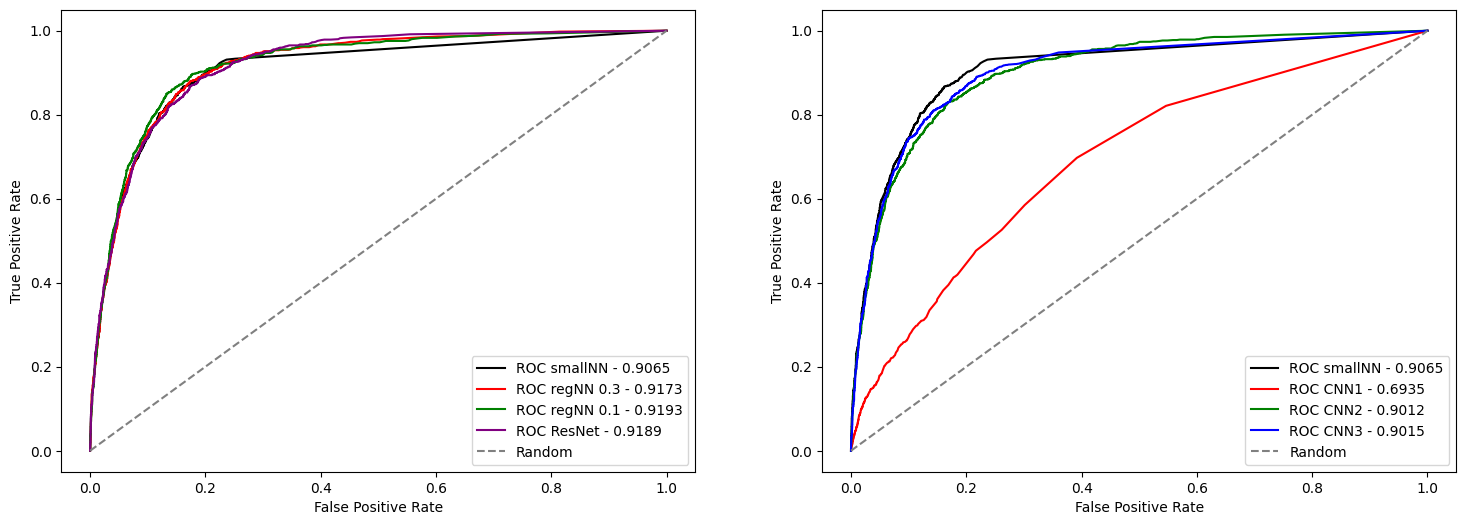

<Figure size 600x600 with 0 Axes>

In [54]:
plot_roc(y_val, bank_smallNN, bank_regNN_03, bank_regNN_01, bank_ResNet, bank_CNN1, bank_CNN2, bank_CNN3, dataset_name)

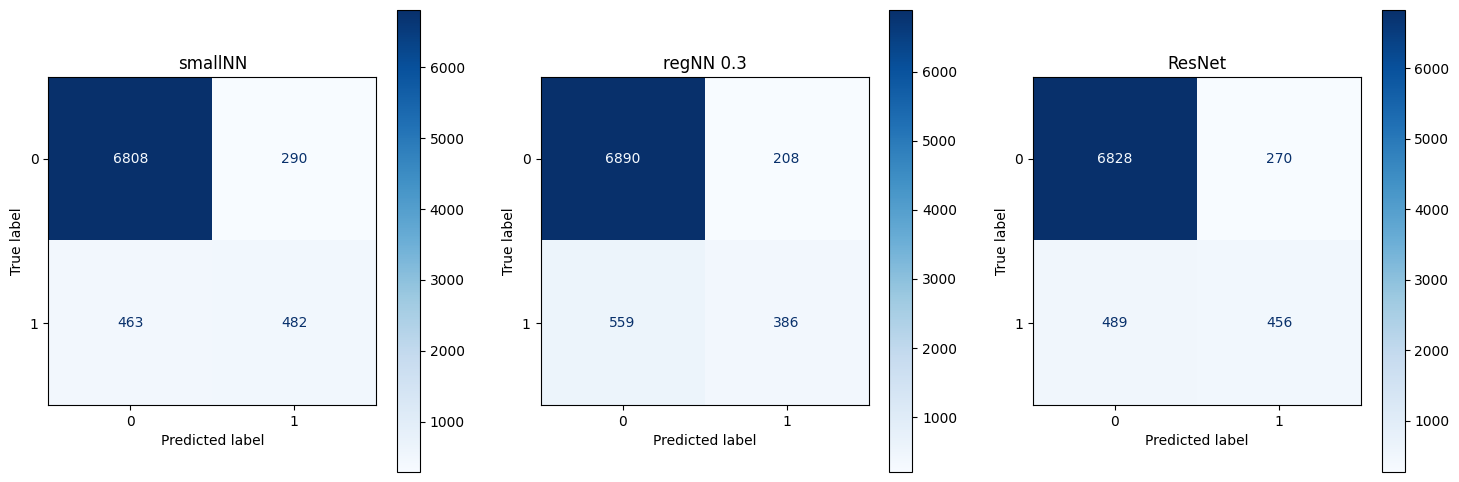

In [55]:
plot_conf_matrix(y_val, bank_smallNN, bank_regNN_03, bank_ResNet, title = ['smallNN', 'regNN 0.3', 'ResNet'])

## **BEANS**

In [ ]:
dataset_name = "beans"
net = nt.load_net(dataset_name)
dataset = ds.Dataset(dataset_name)

feature_names, categorical_features, categorical_names, ordinal, discrete, encoder, num_features = dataset.info()
X_train_or, X_train, y_train = dataset.train()
X_val_or, X_val, y_val = dataset.validation()
X_test_or, X_test, y_test = dataset.test()
print(X_train_or.shape, X_val_or.shape, X_test_or.shape)

beans_smallNN = eval_net(dataset_name, 'model4')

beans_regNN_03 = eval_net(dataset_name, 'model5')
beans_regNN_01 = eval_net(dataset_name, 'model8')
beans_ResNet = eval_net(dataset_name, 'model9')

beans_CNN1  = eval_net(dataset_name, 'model6')
beans_CNN2  = eval_net(dataset_name, 'model7')
beans_CNN3  = eval_net(dataset_name, 'model10')

In [57]:
class_idx = 0
# plot_roc(y_val[class_idx], beans_smallNN[class_idx], beans_regNN_03[class_idx], beans_regNN_01[class_idx], beans_ResNet[class_idx], beans_CNN1[class_idx], beans_CNN2[class_idx], beans_CNN3[class_idx], dataset_name)

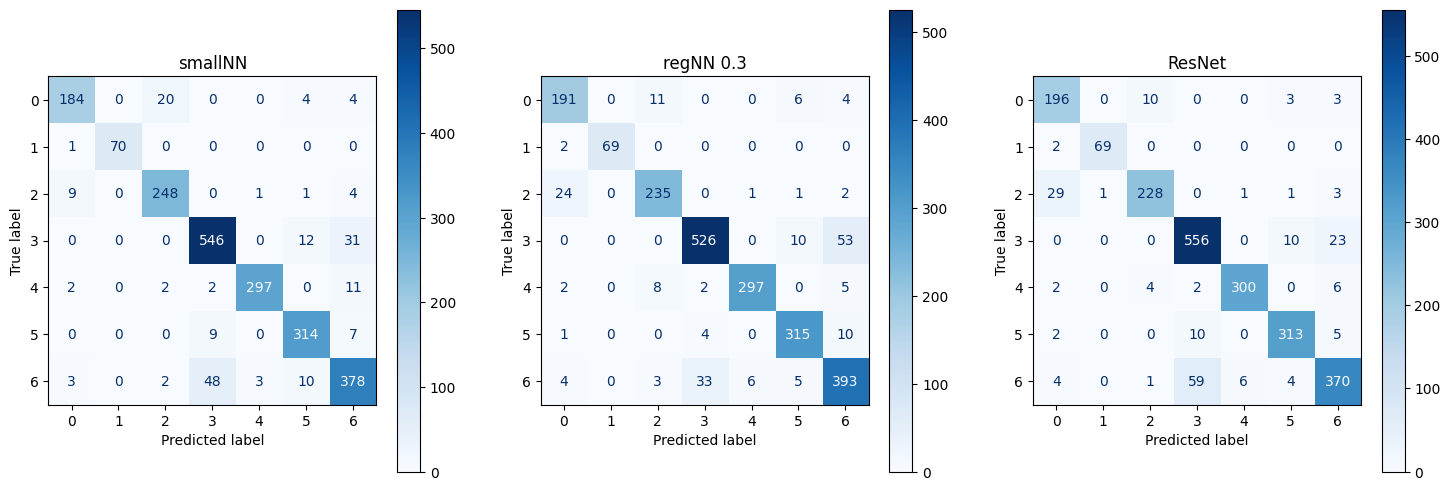

In [58]:
plot_conf_matrix(y_val, beans_smallNN, beans_regNN_03, beans_ResNet, title = ['smallNN', 'regNN 0.3', 'ResNet'])

## **CANCER**

In [ ]:
dataset_name = "cancer"
net = nt.load_net(dataset_name)
dataset = ds.Dataset(dataset_name)

feature_names, categorical_features, categorical_names, ordinal, discrete, encoder, num_features = dataset.info()
X_train_or, X_train, y_train = dataset.train()
X_val_or, X_val, y_val = dataset.validation()
X_test_or, X_test, y_test = dataset.test()
print(X_train_or.shape, X_val_or.shape, X_test_or.shape)

cancer_smallNN = eval_net(dataset_name, 'model4')

cancer_regNN_03 = eval_net(dataset_name, 'model5')
cancer_regNN_01 = eval_net(dataset_name, 'model8')
cancer_ResNet = eval_net(dataset_name, 'model9')

cancer_CNN1  = eval_net(dataset_name, 'model6')
cancer_CNN2  = eval_net(dataset_name, 'model7')
cancer_CNN3  = eval_net(dataset_name, 'model10')

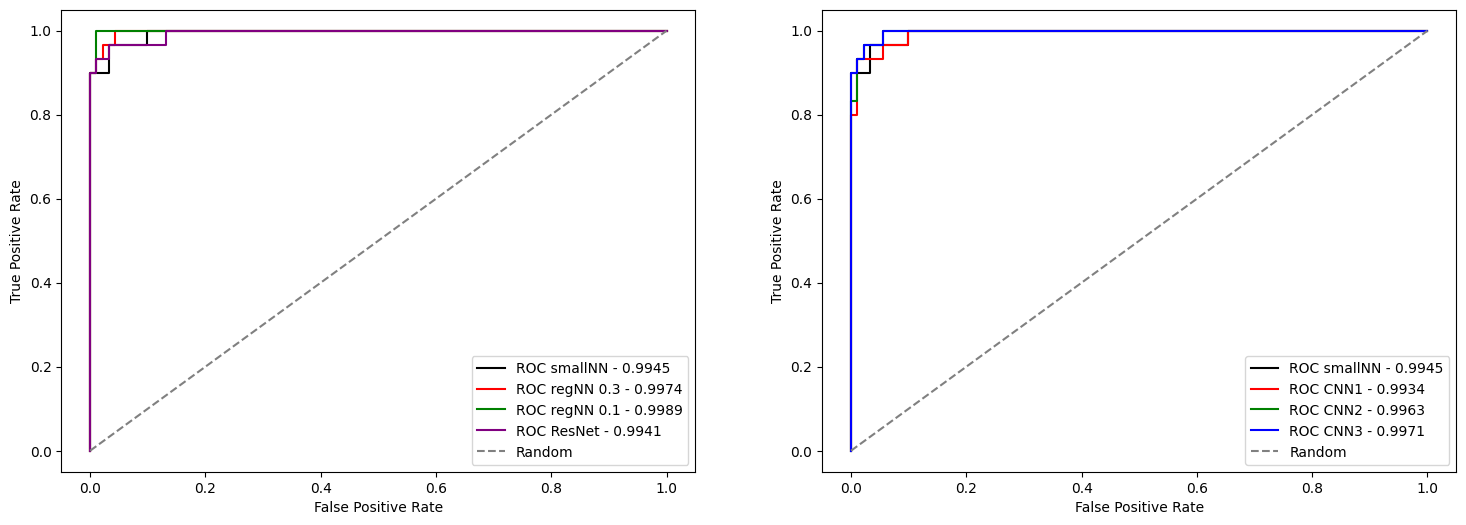

<Figure size 600x600 with 0 Axes>

In [60]:
plot_roc(y_val, cancer_smallNN, cancer_regNN_03, cancer_regNN_01, cancer_ResNet, cancer_CNN1, cancer_CNN2, cancer_CNN3, dataset_name)

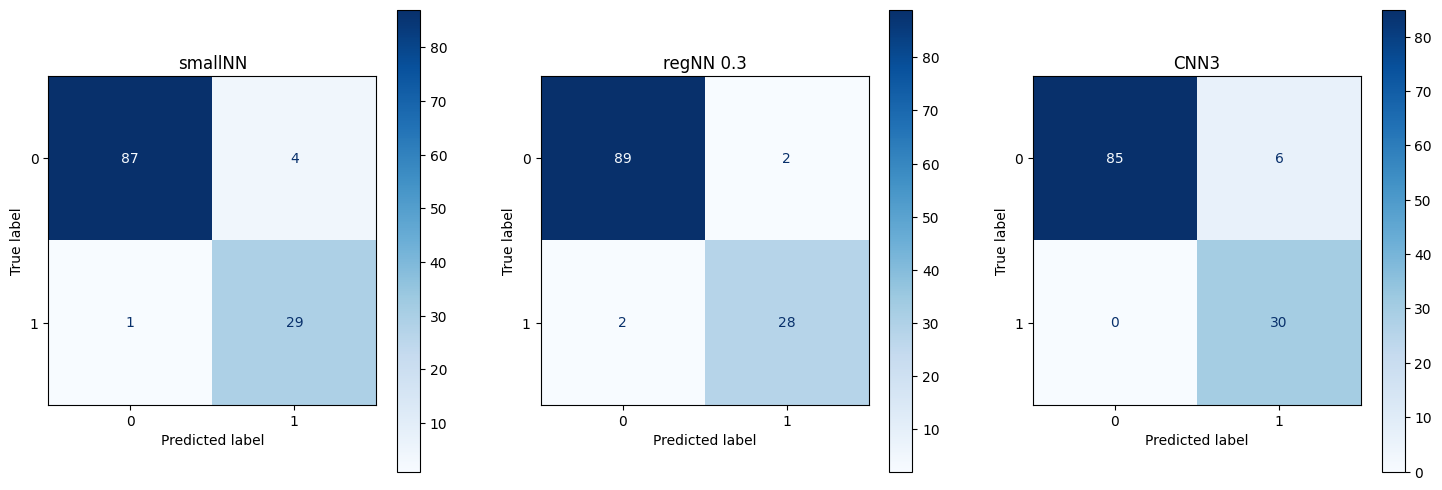

In [61]:
plot_conf_matrix(y_val, cancer_smallNN, cancer_regNN_03, cancer_CNN3, title = ['smallNN', 'regNN 0.3', 'CNN3'])

## **HELOC**

In [ ]:
dataset_name = "heloc"
net = nt.load_net(dataset_name)
dataset = ds.Dataset(dataset_name)

feature_names, categorical_features, categorical_names, ordinal, discrete, encoder, num_features = dataset.info()
X_train_or, X_train, y_train = dataset.train()
X_val_or, X_val, y_val = dataset.validation()
X_test_or, X_test, y_test = dataset.test()
print(X_train_or.shape, X_val_or.shape, X_test_or.shape)

heloc_smallNN = eval_net(dataset_name, 'model4')

heloc_regNN_03 = eval_net(dataset_name, 'model5')
heloc_regNN_01 = eval_net(dataset_name, 'model8')
heloc_ResNet = eval_net(dataset_name, 'model9')

heloc_CNN1  = eval_net(dataset_name, 'model6')
heloc_CNN2  = eval_net(dataset_name, 'model7')
heloc_CNN3  = eval_net(dataset_name, 'model10')

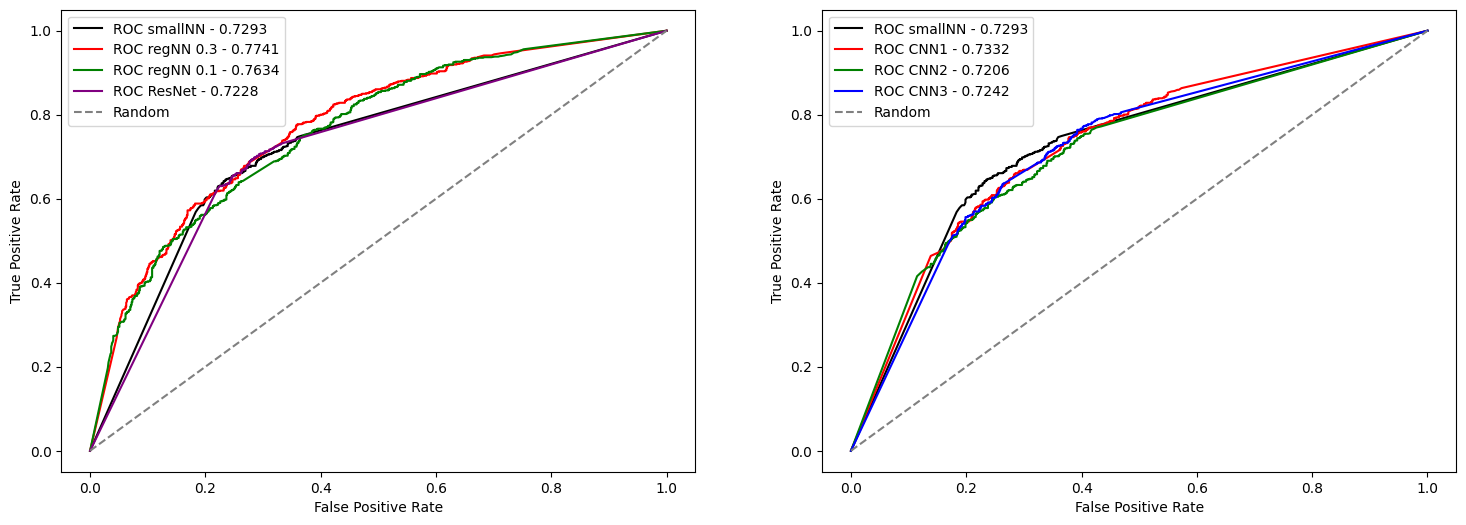

<Figure size 600x600 with 0 Axes>

In [63]:
plot_roc(y_val, heloc_smallNN, heloc_regNN_03, heloc_regNN_01, heloc_ResNet, heloc_CNN1, heloc_CNN2, heloc_CNN3, dataset_name)

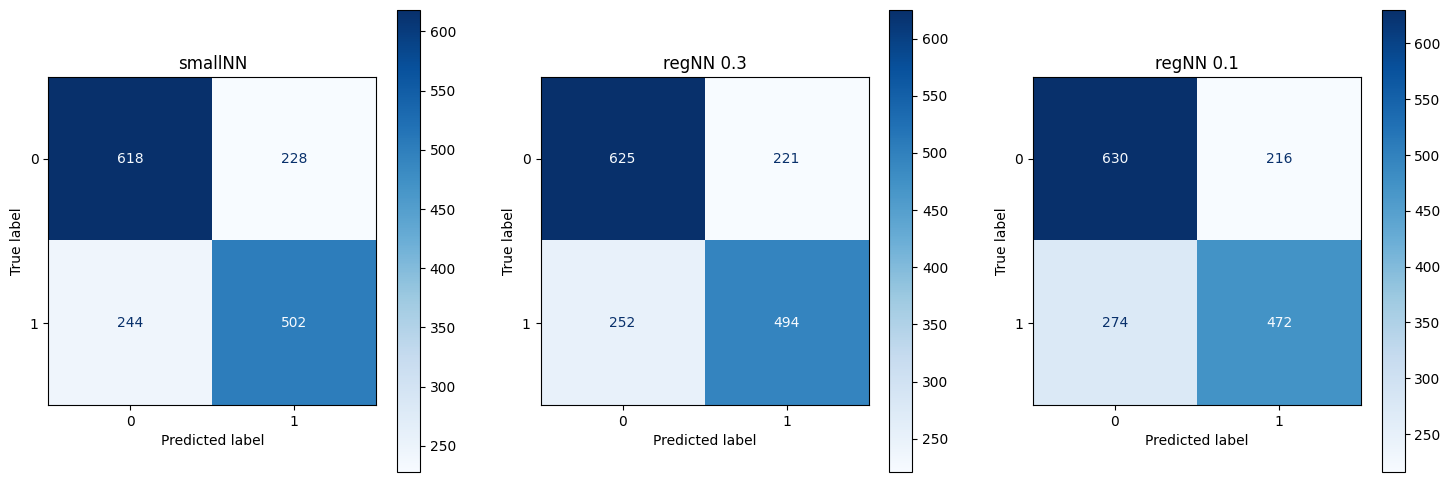

In [64]:
plot_conf_matrix(y_val, heloc_smallNN, heloc_regNN_03, heloc_regNN_01, title = ['smallNN', 'regNN 0.3', 'regNN 0.1'])

## **MUSHROOM**

In [ ]:
dataset_name = "mushroom"
net = nt.load_net(dataset_name)
dataset = ds.Dataset(dataset_name)

feature_names, categorical_features, categorical_names, ordinal, discrete, encoder, num_features = dataset.info()
X_train_or, X_train, y_train = dataset.train()
X_val_or, X_val, y_val = dataset.validation()
X_test_or, X_test, y_test = dataset.test()
print(X_train_or.shape, X_val_or.shape, X_test_or.shape)

mushroom_smallNN = eval_net(dataset_name, 'model4')

mushroom_regNN_03 = eval_net(dataset_name, 'model5')
mushroom_regNN_01 = eval_net(dataset_name, 'model8')
mushroom_ResNet = eval_net(dataset_name, 'model9')

mushroom_CNN1  = eval_net(dataset_name, 'model6')
mushroom_CNN2  = eval_net(dataset_name, 'model7')
mushroom_CNN3  = eval_net(dataset_name, 'model10')

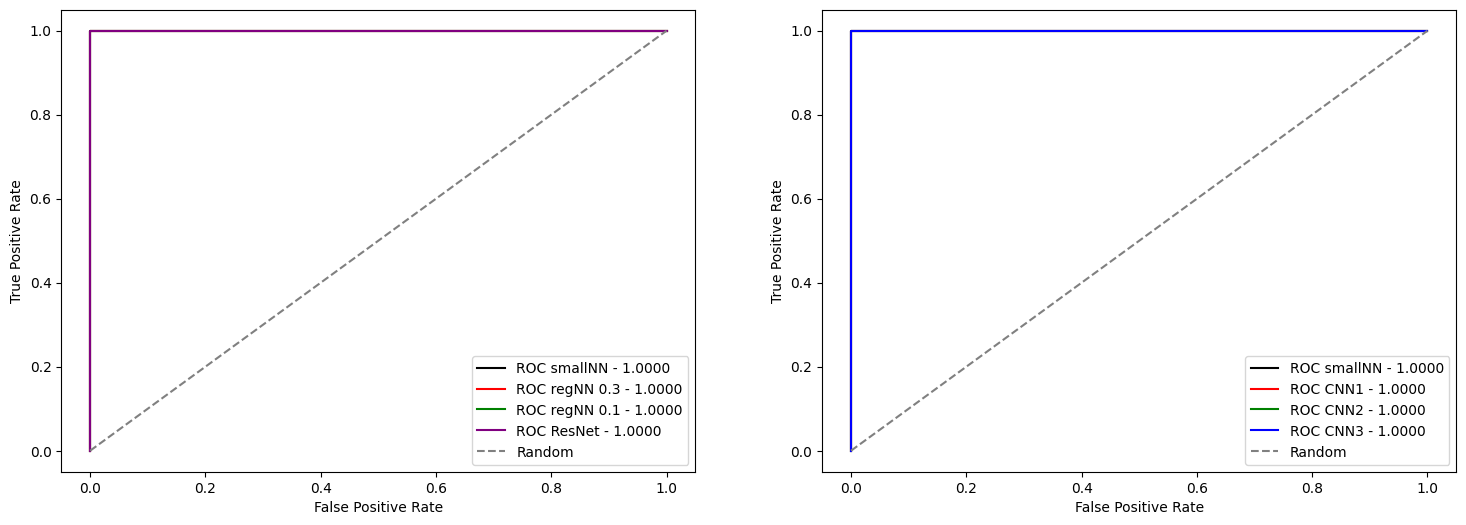

<Figure size 600x600 with 0 Axes>

In [66]:
plot_roc(y_val, mushroom_smallNN, mushroom_regNN_03, mushroom_regNN_01, mushroom_ResNet, mushroom_CNN1, mushroom_CNN2, mushroom_CNN3, dataset_name)

In [67]:
# confusion matrix have 100% accuracy in every model

## **OCEAN**

In [ ]:
dataset_name = "ocean"
net = nt.load_net(dataset_name)
dataset = ds.Dataset(dataset_name)

feature_names, categorical_features, categorical_names, ordinal, discrete, encoder, num_features = dataset.info()
X_train_or, X_train, y_train = dataset.train()
X_val_or, X_val, y_val = dataset.validation()
X_test_or, X_test, y_test = dataset.test()
print(X_train_or.shape, X_val_or.shape, X_test_or.shape)

ocean_smallNN = eval_net(dataset_name, 'model4')

ocean_regNN_03 = eval_net(dataset_name, 'model5')
ocean_regNN_01 = eval_net(dataset_name, 'model8')
ocean_ResNet = eval_net(dataset_name, 'model9')

ocean_CNN1  = eval_net(dataset_name, 'model6')
ocean_CNN2  = eval_net(dataset_name, 'model7')
ocean_CNN3  = eval_net(dataset_name, 'model10')

In [69]:
class_idx = 0
# plot_roc(y_val[class_idx], ocean_smallNN[class_idx], ocean_regNN_03[class_idx], ocean_regNN_01[class_idx], ocean_ResNet[class_idx], ocean_CNN1[class_idx], ocean_CNN2[class_idx], ocean_CNN3[class_idx], dataset_name)

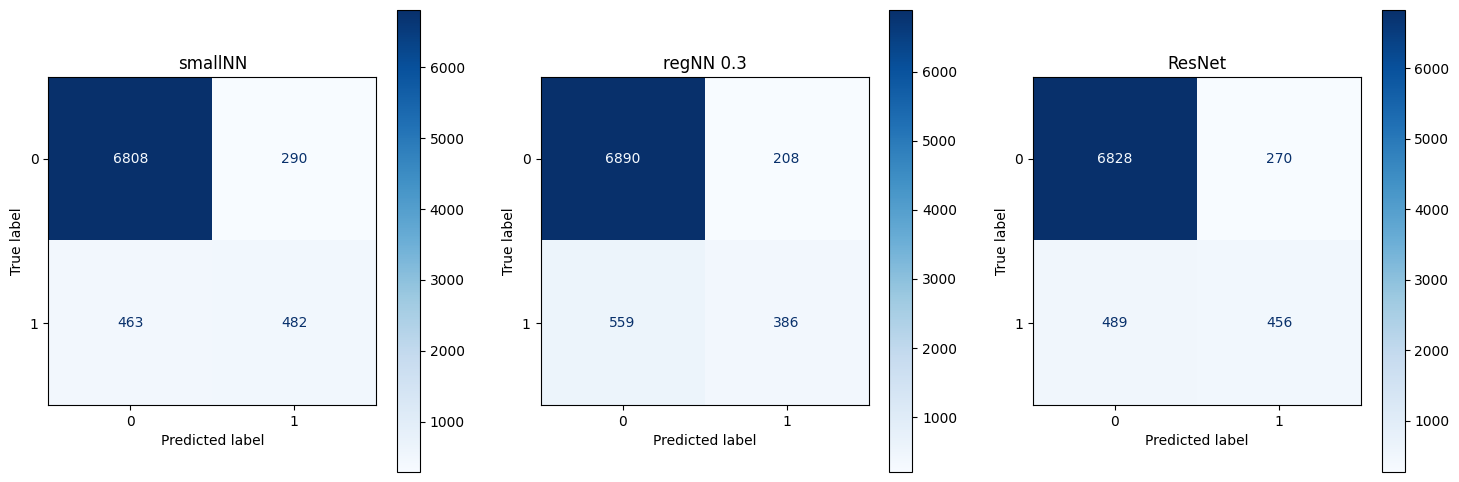

In [70]:
plot_conf_matrix(y_val, bank_smallNN, bank_regNN_03, bank_ResNet, title = ['smallNN', 'regNN 0.3', 'ResNet'])

## **WINE**

In [ ]:
dataset_name = "wine"
net = nt.load_net(dataset_name)
dataset = ds.Dataset(dataset_name)

feature_names, categorical_features, categorical_names, ordinal, discrete, encoder, num_features = dataset.info()
X_train_or, X_train, y_train = dataset.train()
X_val_or, X_val, y_val = dataset.validation()
X_test_or, X_test, y_test = dataset.test()
print(X_train_or.shape, X_val_or.shape, X_test_or.shape)

wine_smallNN = eval_net(dataset_name, 'model4')

wine_regNN_03 = eval_net(dataset_name, 'model5')
wine_regNN_01 = eval_net(dataset_name, 'model8')
wine_ResNet = eval_net(dataset_name, 'model9')

wine_CNN1  = eval_net(dataset_name, 'model6')
wine_CNN2  = eval_net(dataset_name, 'model7')
wine_CNN3  = eval_net(dataset_name, 'model10')

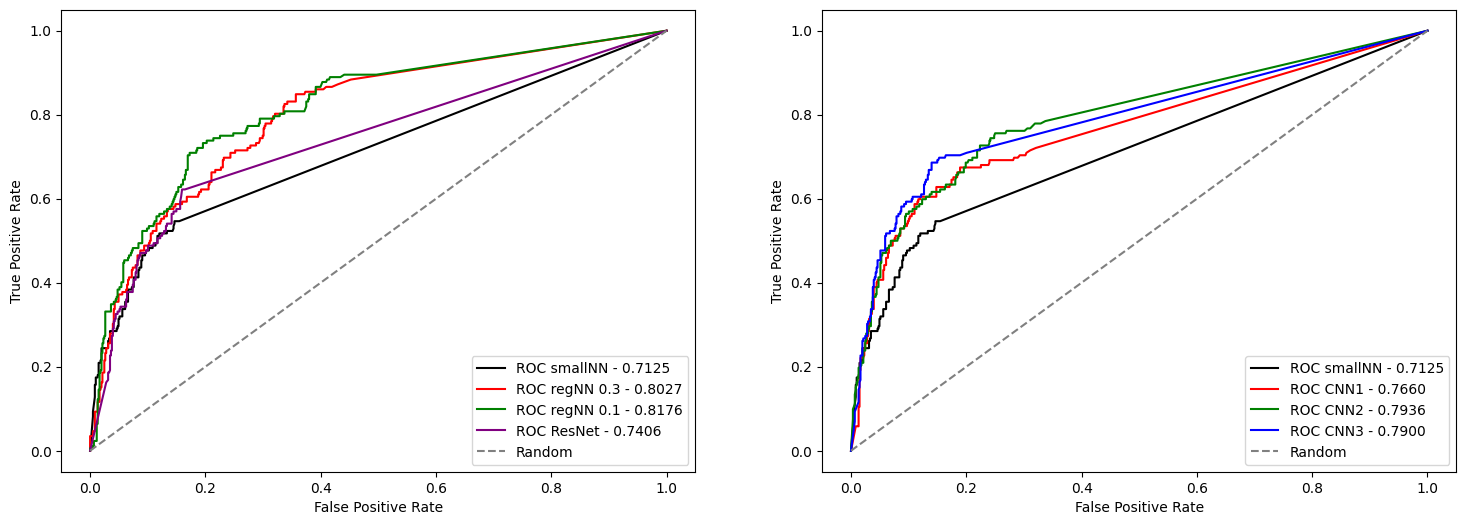

<Figure size 600x600 with 0 Axes>

In [72]:
plot_roc(y_val, wine_smallNN, wine_regNN_03, wine_regNN_01, wine_ResNet, wine_CNN1, wine_CNN2, wine_CNN3, dataset_name)

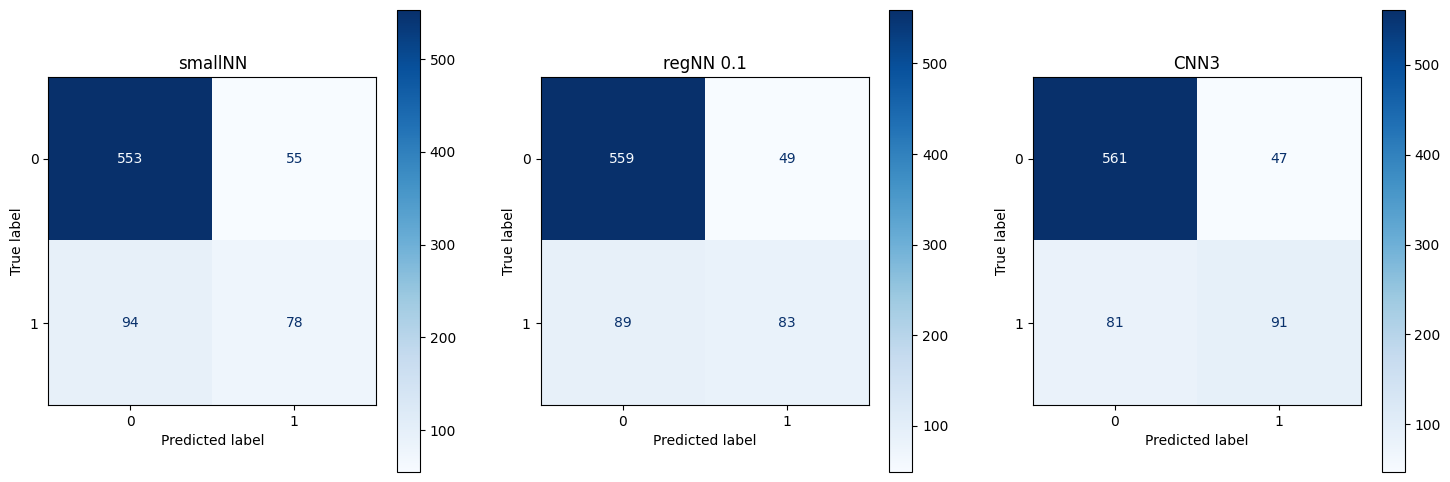

In [73]:
plot_conf_matrix(y_val, wine_smallNN, wine_regNN_01, wine_CNN3, title = ['smallNN', 'regNN 0.1', 'CNN3'])

# **Conclusioni**

rispetto al modello baseline smallNN:

- Regolarizzazione attraverso batchnorm e dropout migliorano le performance, 
- CNN <ins>non</ins> migliorano le performance perché i dati tabellari non hanno patterns sulle colonne
- Residual Net migliora in parte le performance